 # GNN: Representation Learning - Theory

*Efficient, task-independent feature learning on graphs*

<div align="center">

![diagram](./gnn-drawing.png)

</div>

### Why Embedding?

Map nodes into an embedding space where similarity between embeddings reflects structural similarity in the network. A single learned embedding can serve many downstream tasks:

| Task | Description |
|------|-------------|
| Node classification | Predict the label/category of a node |
| Link prediction | Predict missing or future edges |
| Clustering | Group structurally similar nodes |
| Graph classification | Classify entire graphs |


## Node Embeddings

Goal: encode nodes so that **similarity in embedding space approximates similarity in the graph**.

$$f(u) : V \rightarrow \mathbb{R}^d \qquad \text{similarity}(z_u, z_v) \approx \text{similarity in graph}$$

<div align="center">
  <div style="display:inline-block; background-color:white; padding:12px; border-radius:6px;">
    <img src="./gnn-drawing11.png" />
  </div>
</div>

---

### Measuring Similarity — Inner Products

The choice of inner product defines the **geometry** of the embedding space:

| Inner Product | Formula | Notes |
|---|---|---|
| Dot product | $z_u^\top z_v$ | Fast, symmetric, mixes magnitude + direction |
| Cosine | $\frac{z_u^\top z_v}{\|z_u\|\|z_v\|}$ | Direction only, ignores magnitude |
| Bilinear (SPD) | $z_u^\top M z_v$ | M learned, weights dimensions differently |
| Complex | $\text{Re}(z_u^\top \bar{z}_v)$ | Asymmetric similarity, good for directed graphs |

---

### Dot Product = Angle Between Vectors

$$z_u^\top z_v = \|z_u\| \|z_v\| \cos(\theta)$$

The dot product measures **how much of $z_v$ projects onto $z_u$**:

- $\theta = 0°$ → $\cos\theta = 1$ → maximally similar  
- $\theta = 90°$ → $\cos\theta = 0$ → no similarity  
- $\theta = 180°$ → $\cos\theta = -1$ → maximally dissimilar  

Scalar projection (shadow length of $z_v$ along $z_u$):

$$\text{proj}_{z_u}(z_v) = \frac{z_u^\top z_v}{\|z_u\|}$$

> **High dot product** can mean truly similar *or* just large magnitude vectors — high-degree nodes accumulate large norms during training, inflating their dot product with everyone.

---

### Normalisation

Scale a vector to length 1, keeping direction unchanged:

$$\hat{z} = \frac{z}{\|z\|} = \frac{z}{\sqrt{z_1^2 + z_2^2 + \cdots + z_d^2}}$$

When $\|z_u\| = \|z_v\| = 1$, magnitude terms drop out and dot product collapses into cosine similarity:

$$z_u^\top z_v = \underbrace{\|z_u\|}_{1} \underbrace{\|z_v\|}_{1} \cos(\theta) = \cos(\theta)$$

All vectors live on a **unit hypersphere** — only direction can vary, so dot product measures angle only.

| | Unnormalised | Normalised |
|---|---|---|
| Dot product | angle + magnitude | angle only |
| High-degree nodes | dominate similarity | treated equally |
| Interpretation | ambiguous | safe — purely directional |

---

### Enforcing Valid Inner Products — SPD Constraint

For $z_u^\top M z_v$ to be a valid inner product, **M must be Symmetric Positive Definite**:

1. **Symmetry**: $M = M^\top$  
2. **Positive definite**: $x^\top M x > 0 \;\forall x \neq 0$

Enforce by construction (not projection):

| Parametrisation | Formula | Why it works |
|---|---|---|
| Cholesky | $M = LL^\top$ | $LL^\top$ is always SPD |
| Quadratic | $M = A^\top A + \varepsilon I$ | $A^\top A$ is PSD, $+\varepsilon I$ makes it PD |
| Diagonal | $M = \text{diag}(\text{softplus}(w))$ | Simplest, positive diagonal guaranteed |


## Encoder — Decoder Framework

The general recipe for learning node embeddings:

```
Graph                Embedding Space              Reconstruction
  u  ──► ENC(u) ──► z_u ─┐
                           ├──► DEC(z_u, z_v) ──► similarity score
  v  ──► ENC(v) ──► z_v ─┘
```

$$\text{DEC}(\text{ENC}(u),\ \text{ENC}(v)) \approx \text{similarity}(u, v)$$

- **Encoder** — compresses node identity/structure into $z \in \mathbb{R}^d$
- **Decoder** — reconstructs graph relationships from embeddings (usually dot product)
- **Train** — minimise reconstruction loss so connected nodes score high, disconnected nodes score low

---

### Shallow Encoder

The simplest encoder — a **lookup table**, nothing more:

$$\text{ENC}(u) = Z \cdot \mathbf{v}_u$$

- $Z \in \mathbb{R}^{d \times |V|}$ — embedding matrix, one column per node
- $\mathbf{v}_u$ — one-hot vector, selects column $u$ from $Z$

No computation happens. No neighbours consulted. Just fetch the pre-learned vector:

```
Z = [ z_1 | z_2 | z_3 | ... | z_n ]
                    ↑
              ENC(node 3) = z_3
```

What gets learned is only $Z$ — a separate $d$-dimensional vector for every node independently.

---

### Shallow Encoder Algorithms

| Algorithm | How Z is learned | Walk strategy |
|---|---|---|
| **DeepWalk** | Random walks → treated as sentences → Word2Vec (Skip-gram) on node sequences | Uniform random |
| **node2vec** | Same as DeepWalk but biased walks control BFS vs DFS exploration | BFS = structural, DFS = community |
| **LINE** | Directly optimise first-order (direct edges) + second-order (shared neighbours) proximity | No walks |

All three share the **same encoder** — a lookup table Z. They differ only in how they define "similar nodes" to drive the training signal.

---

### Limitations of Shallow Encoders

**1. Transductive — cannot handle unseen nodes**

At inference, only nodes seen during training have an embedding:

```
node 42 → Z[:, 42]  ✓  seen during training
node 99 → Z[:, 99]  ✗  new node — no column exists in Z
```

> Memorises, not generalises. Like a student who learned answers by rote — ask a new question and they fail.

**2. Parameters don't scale**

$$\text{parameters} = d \times |V|$$

1M nodes, 128-dim embeddings → 128M parameters just for the table. No sharing across nodes.

**3. Node features ignored**

Z is learned purely from graph structure. Any attributes on nodes (age, text, features) are discarded.

**4. No structural sharing**

Two nodes with identical neighbourhoods get completely independent vectors — the encoder has no way to recognise they are structurally equivalent.

---

### Shallow vs Deep (GNN) Encoder

| | Shallow Encoder | GNN Encoder |
|---|---|---|
| Formula | $Z \cdot \mathbf{v}_u$ (lookup) | $\text{GNN}(A, X, u)$ (computation) |
| Unseen nodes | fails | computes from neighbours |
| Node features | ignored | used |
| Parameters | $d \times \|V\|$ | shared weights, much fewer |
| Learning type | transductive | inductive |
| Examples | DeepWalk, node2vec, LINE | GCN, GraphSAGE, GAT |


## Random Walk Algorithm — Full View

**Goal:** learn embeddings $Z$ such that nodes that co-occur on random walks end up close together in embedding space.

$$\text{similarity}(u, v) \approx P(v \mid z_u)$$

---

### Step 1 — Generate Walks

```
Input:  Graph G = (V, E)
        L = walk length
        R = walks per node

for each node u in V:
    for r = 1 to R:
        walk = [u]
        for step = 1 to L:
            current = walk[-1]
            next    = random neighbour of current      # P(v|u) = 1/deg(u)
            walk.append(next)
        save walk
```

Example walk (L = 4): `u → 2 → 5 → 3 → 6`

---

### Step 2 — Build Co-occurrence Pairs (Window)

Slide a window of size $k$ across each walk. Every pair of nodes inside the window becomes a **positive training pair**.

```
walk:    u   2   5   3   6
window (k=2) centered on "5":   [u, 2, 5, 3, 6]
                                       ↑
positive pairs from "5":  (5,u) (5,2) (5,3) (5,6)
```

This repeats for every node in every walk → produces the full set of positive pairs $N_R(u)$.

---

### Step 3 — Train Embeddings (Skip-gram objective)

```
Initialise Z randomly

for each positive pair (u, v) from Step 2:
    maximise   log P(v | z_u)  =  log softmax(z_u^T z_v)

    # negative sampling in practice:
    sample k_neg random nodes n1...n_kneg (not connected to u)
    minimise   z_u^T z_n   for each negative sample
```

$$\max_Z \sum_{u \in V} \sum_{v \in N_R(u)} \log P(v \mid z_u), \qquad P(v \mid z_u) = \frac{\exp(z_u^\top z_v)}{\sum_{n \in V} \exp(z_u^\top z_n)}$$

---

### What Walk Length ($L$) Controls

Walk length is **how many steps each walk takes** before stopping.

| Small $L$ | Large $L$ |
|---|---|
| Captures only local/direct neighbours | Captures distant, global structure |
| Embeddings reflect immediate connectivity | Embeddings drift toward whole-graph community structure |
| Cheaper to compute | More expensive — longer sequences |
| Risk: misses larger community patterns | Risk: walk "forgets" where it started (random walks mix) |

Think of $L$ as **how far you let the walk wander away from the start node** before recording where it ended up.

---

### What Window Size ($k$) Controls

Window size is **how many neighbouring positions in the walk count as "context"** for a given node — exactly like Word2Vec's context window for words in a sentence.

```
walk:  u  2  5  3  6  1  4
              ↑
        window k=1:  pairs with {3, 6}        ← narrow context
        window k=2:  pairs with {u,2,3,6,1}   ← wider context
```

| Small $k$ | Large $k$ |
|---|---|
| Only very close walk-neighbours count as similar | Distant walk-positions also count as similar |
| Sharper, more local similarity signal | Smoother, more global similarity signal |
| Fewer training pairs generated | Many more training pairs generated (slower) |

$L$ controls **how far the walk explores**; $k$ controls **how far within that walk two nodes can be and still be called "similar"**.

---

### Panoptic View

```
                    ┌───────────────────────────────┐
                    │   Hyperparameters: L, R, k, d  │
                    └───────────────┬───────────────┘
                                    │
        ┌───────────────────────────▼───────────────────────────┐
        │  STEP 1: Random Walks                                  │
        │  Graph  →  R walks of length L per node                │
        └───────────────────────────┬───────────────────────────┘
                                    │ walks
        ┌───────────────────────────▼───────────────────────────┐
        │  STEP 2: Windowing                                     │
        │  Slide window k over each walk → positive pairs (u,v)  │
        └───────────────────────────┬───────────────────────────┘
                                    │ (u,v) pairs
        ┌───────────────────────────▼───────────────────────────┐
        │  STEP 3: Train Embeddings (Skip-gram + Neg. Sampling)  │
        │  ENC(u) = Z·v_u      DEC(z_u,z_v) = softmax(z_u^T z_v) │
        │  max Σ log P(v | z_u)                                  │
        └───────────────────────────┬───────────────────────────┘
                                    │
                                    ▼
                        Final embedding matrix Z
```

---

### Hyperparameter Summary

| Parameter | Controls | Trade-off |
|---|---|---|
| $L$ — walk length | How far each walk travels from start node | local (small) vs global (large) structure |
| $R$ — walks per node | How many times each node is sampled | coverage vs compute cost |
| $k$ — window size | How wide the co-occurrence context is | sharp vs smooth similarity signal |
| $d$ — embedding dim | Capacity of each embedding vector | expressiveness vs overfitting/cost |


## Random Walk - Implementation

In [5]:
import numpy as np
import networkx as nx
from collections import defaultdict

class RandomWalkEmbedding:
    """
    Random Walk Node Embedding
    --------------------------
    Encoder : Z (lookup table)  — maps node id → d-dim vector
    Decoder : dot product       — scores similarity of two embeddings
    Signal  : random walks      — defines which node pairs are "similar"
    """

    def __init__(self, graph, dim=16, walk_length=10, walks_per_node=5, window=3, lr=0.01, neg_samples=5):
        self.G          = graph
        self.nodes      = list(graph.nodes())
        self.n          = len(self.nodes)
        self.node2idx   = {n: i for i, n in enumerate(self.nodes)}

        # hyperparameters
        self.dim            = dim            # d  — embedding dimension
        self.walk_length    = walk_length    # L  — how far each walk travels
        self.walks_per_node = walks_per_node # R  — walks per node
        self.window         = window         # k  — context window size
        self.lr             = lr
        self.neg_samples    = neg_samples

        # ------------------------------------------------------------------ #
        #  ENCODER — Z is the only learned parameter                          #
        #  ENC(u) = Z[:, u]  (lookup column u from embedding matrix)         #
        # ------------------------------------------------------------------ #
        self.Z = np.random.randn(self.n, self.dim) * 0.01   # shape: (|V|, d)

    # ------------------------------------------------------------------ #
    #  ENCODER                                                            #
    # ------------------------------------------------------------------ #
    def encode(self, node):
        """ENC(u) = Z[u] — fetch the embedding vector for a node."""
        idx = self.node2idx[node]
        return self.Z[idx]

    # ------------------------------------------------------------------ #
    #  DECODER                                                            #
    # ------------------------------------------------------------------ #
    def decode(self, z_u, z_v):
        """DEC(z_u, z_v) = sigmoid(z_u · z_v) — similarity score in [0,1]."""
        return 1 / (1 + np.exp(-np.dot(z_u, z_v)))

    def similarity(self, u, v):
        """Convenience: encode both nodes then decode."""
        return self.decode(self.encode(u), self.encode(v))

    # ------------------------------------------------------------------ #
    #  RANDOM WALK — defines the training signal                          #
    # ------------------------------------------------------------------ #
    def _single_walk(self, start):
        """Run one random walk of length L starting from `start`."""
        walk = [start]
        for _ in range(self.walk_length - 1):
            current   = walk[-1]
            neighbours = list(self.G.neighbors(current))
            if not neighbours:
                break
            walk.append(np.random.choice(neighbours))   # P(v|u) = 1/deg(u)
        return walk

    def generate_walks(self):
        """Run R walks per node → corpus of walks (Step 1)."""
        walks = []
        for node in self.nodes:
            for _ in range(self.walks_per_node):
                walks.append(self._single_walk(node))
        np.random.shuffle(walks)
        return walks

    def _get_pairs(self, walks):
        """Slide window k over each walk → positive (u,v) pairs (Step 2)."""
        pairs = []
        for walk in walks:
            for i, u in enumerate(walk):
                lo = max(0, i - self.window)
                hi = min(len(walk), i + self.window + 1)
                for j in range(lo, hi):
                    if i != j:
                        pairs.append((u, walk[j]))
        return pairs

    # ------------------------------------------------------------------ #
    #  TRAINING — skip-gram with negative sampling (Step 3)               #
    # ------------------------------------------------------------------ #
    def _negative_sample(self, exclude):
        """Sample a random node that is not in `exclude`."""
        while True:
            n = np.random.choice(self.nodes)
            if n not in exclude:
                return n

    def _update(self, u, v, label):
        """
        One SGD step.
          label=1 → positive pair  (push z_u · z_v up)
          label=0 → negative pair  (push z_u · z_v down)
        """
        iu, iv   = self.node2idx[u], self.node2idx[v]
        z_u, z_v = self.Z[iu], self.Z[iv]

        score = self.decode(z_u, z_v)          # sigmoid(z_u · z_v)
        error = label - score                  # gradient signal

        # update both embeddings
        self.Z[iu] += self.lr * error * z_v
        self.Z[iv] += self.lr * error * z_u

    def train(self, epochs=10, verbose=True):
        for epoch in range(epochs):
            walks = self.generate_walks()
            pairs = self._get_pairs(walks)
            np.random.shuffle(pairs)

            total_loss = 0
            for u, v in pairs:
                # --- positive pair ---
                self._update(u, v, label=1)

                # --- negative samples ---
                neighbours = set(self.G.neighbors(u)) | {u}
                for _ in range(self.neg_samples):
                    neg = self._negative_sample(exclude=neighbours)
                    self._update(u, neg, label=0)

                # binary cross-entropy loss (for logging)
                s = self.decode(self.encode(u), self.encode(v))
                total_loss += -np.log(s + 1e-10)

            if verbose:
                print(f"Epoch {epoch+1}/{epochs}  loss={total_loss/len(pairs):.4f}  pairs={len(pairs)}")

        return self.Z

CORA — Dataset Overview
Nodes              : 2708
Edges              : 10556
Classes            : 7
Node feature dim   : 1433  (bag-of-words)
Train / Val / Test : 140 / 500 / 1000

Weakly connected components : 78
Main component  — nodes     : 2485
Main component  — edges     : 10138

Degree    min/max/avg : 2 / 336 / 8.16
In-deg    min/max/avg : 1 / 168 / 4.08  ← times cited
Out-deg   min/max/avg : 1 / 168 / 4.08  ← papers cited

Class distribution (main component):
  0  Theory                     344 nodes
  1  Reinforcement_Learning     214 nodes
  2  Genetic_Algorithms         406 nodes
  3  Neural_Networks            726 nodes
  4  Probabilistic_Methods      379 nodes
  5  Case_Based                 285 nodes
  6  Rule_Learning              131 nodes


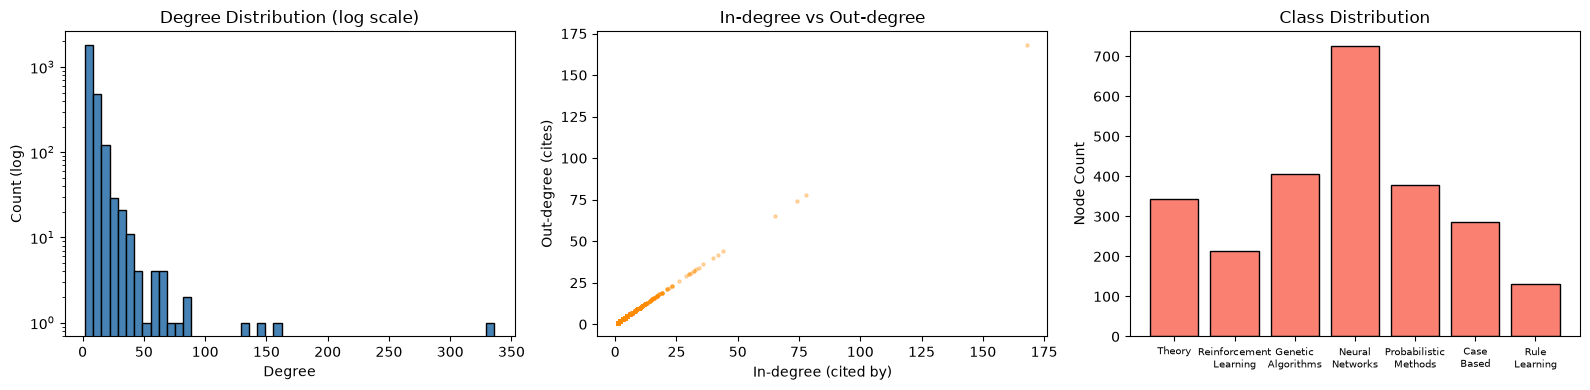

In [6]:

# ── Cora EDA ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data    = dataset[0]

class_names = [
    "Theory", "Reinforcement_Learning", "Genetic_Algorithms",
    "Neural_Networks", "Probabilistic_Methods", "Case_Based", "Rule_Learning"
]

print("=" * 45)
print("CORA — Dataset Overview")
print("=" * 45)
print(f"Nodes              : {data.num_nodes}")
print(f"Edges              : {data.num_edges}")
print(f"Classes            : {dataset.num_classes}")
print(f"Node feature dim   : {data.num_node_features}  (bag-of-words)")
print(f"Train / Val / Test : {data.train_mask.sum()} / {data.val_mask.sum()} / {data.test_mask.sum()}")

# --- Build NetworkX graph → keep largest weakly connected component ---
G       = to_networkx(data, to_undirected=False)
largest = max(nx.weakly_connected_components(G), key=len)
G_main  = G.subgraph(largest).copy()

print(f"\nWeakly connected components : {len(list(nx.weakly_connected_components(G)))}")
print(f"Main component  — nodes     : {G_main.number_of_nodes()}")
print(f"Main component  — edges     : {G_main.number_of_edges()}")

# --- Degree stats ---
degrees     = [d for _, d in G_main.degree()]
in_degrees  = [d for _, d in G_main.in_degree()]
out_degrees = [d for _, d in G_main.out_degree()]

print(f"\nDegree    min/max/avg : {min(degrees)} / {max(degrees)} / {np.mean(degrees):.2f}")
print(f"In-deg    min/max/avg : {min(in_degrees)} / {max(in_degrees)} / {np.mean(in_degrees):.2f}  ← times cited")
print(f"Out-deg   min/max/avg : {min(out_degrees)} / {max(out_degrees)} / {np.mean(out_degrees):.2f}  ← papers cited")

# --- Class distribution ---
node_ids = list(G_main.nodes())
labels   = data.y[node_ids].numpy()

print("\nClass distribution (main component):")
counts = [Counter(labels)[i] for i in range(7)]
for i, (name, cnt) in enumerate(zip(class_names, counts)):
    print(f"  {i}  {name:<25}  {cnt} nodes")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Degree distribution
axes[0].hist(degrees, bins=50, color='steelblue', edgecolor='black', log=True)
axes[0].set_title("Degree Distribution (log scale)")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count (log)")

# 2. In vs Out degree scatter
axes[1].scatter(in_degrees, out_degrees, alpha=0.3, s=5, color='darkorange')
axes[1].set_xlabel("In-degree (cited by)")
axes[1].set_ylabel("Out-degree (cites)")
axes[1].set_title("In-degree vs Out-degree")

# 3. Class distribution bar
axes[2].bar(range(7), counts, color='salmon', edgecolor='black')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels([c.replace("_", "\n") for c in class_names], fontsize=7)
axes[2].set_ylabel("Node Count")
axes[2].set_title("Class Distribution")

plt.tight_layout()
plt.show()


In [8]:

# ── Train RandomWalkEmbedding on Cora ─────────────────────────────────────
# depends on: G_main, data, class_names  (from EDA cell above)

G_undirected = G_main.to_undirected()

model_cora = RandomWalkEmbedding(
    graph          = G_undirected,
    dim            = 64,
    walk_length    = 5,   # L — long walks capture community structure
    walks_per_node = 2,   # R — 10 walks per node
    window         = 3,    # k — context window
    lr             = 0.025,
    neg_samples    = 5,
)

print(f"Nodes: {G_undirected.number_of_nodes()}  Edges: {G_undirected.number_of_edges()}")
print(f"Params — d=64  L=10  R=3  k=3  lr=0.025\n")

if 'Z_cora' not in dir():   # only runs if Z_cora doesn't exist yet
    Z_cora = model_cora.train(epochs=10)

print("\nEmbedding matrix shape:", Z_cora.shape)

Nodes: 2485  Edges: 5069
Params — d=64  L=10  R=3  k=3  lr=0.025

Epoch 1/10  loss=0.6910  pairs=89460
Epoch 2/10  loss=0.6611  pairs=89460
Epoch 3/10  loss=0.5723  pairs=89460
Epoch 4/10  loss=0.4289  pairs=89460
Epoch 5/10  loss=0.2900  pairs=89460
Epoch 6/10  loss=0.1993  pairs=89460
Epoch 7/10  loss=0.1495  pairs=89460
Epoch 8/10  loss=0.1201  pairs=89460
Epoch 9/10  loss=0.1061  pairs=89460
Epoch 10/10  loss=0.0964  pairs=89460

Embedding matrix shape: (2485, 64)



Running t-SNE...


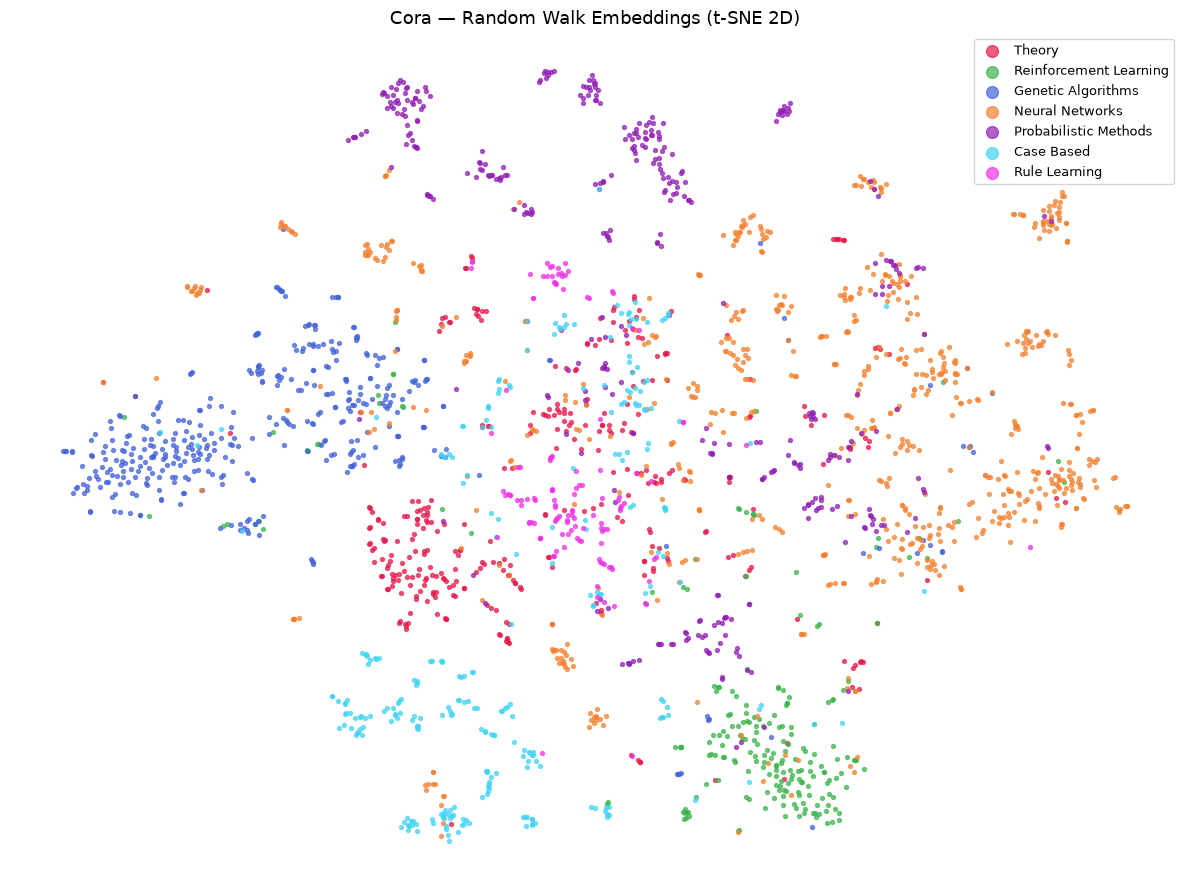


=== Similarity sanity check ===
  sim(   0,  633) = 0.8344   same_class=True
  sim(   0, 1862) = 0.9061   same_class=True
  sim(   0, 2582) = 0.8510   same_class=True
  sim(   1,    2) = 0.6754   same_class=True
  sim(   1,  652) = 0.6111   same_class=True


In [ ]:
# ── Reduce to 2D with t-SNE ───────────────────────────────────────────────
from sklearn.manifold import TSNE

print("\nRunning t-SNE...")
Z_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(Z_cora)

# align labels to model node order
y_aligned = data.y[model_cora.nodes].numpy()


# ── Plot ───────────────────────────────────────────────────────────────────
colors = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4','#f032e6']

fig, ax = plt.subplots(figsize=(12, 9))
for cls_id, (name, color) in enumerate(zip(class_names, colors)):
    mask = y_aligned == cls_id
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               c=color, label=name.replace('_', ' '), s=8, alpha=0.7)

ax.legend(markerscale=3, fontsize=9)
ax.set_title("Cora — Random Walk Embeddings (t-SNE 2D)", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


# ── Sanity check — connected nodes should score higher ────────────────────
print("\n=== Similarity sanity check ===")
for u, v in list(G_undirected.edges())[:5]:
    s    = model_cora.similarity(u, v)
    same = data.y[u].item() == data.y[v].item()
    print(f"  sim({u:4d}, {v:4d}) = {s:.4f}   same_class={same}")


## Notes

## Experiments